Анализ рынка недвижимости России 2021

Цель проекта — исследовать рынок новостроек на открытом датасете объявлений о продаже недвижимости в России за 2021 год и построить простые модели, которые по характеристикам объекта предсказывают цену за квадратный метр.


Вопросы, на которые отвечает проект
 - Какие факторы сильнее всего влияют на цену за квадратный метр новостройки (регион, этажность, площадь, планировка и т.п.)?
 - Насколько хорошо можно предсказывать цену за м², используя только базовые характеристики квартиры и дома?
 - Какие признаки оказываются наиболее важными для модели и совпадает ли это с интуитивными и EDA‑выводами?


Описание данных
Источник: открытый датасет объявлений о продаже недвижимости в России за 2021 год (Russia Real Estate 2021).

Набор полей (используемые в проекте):

- price — цена объекта;
- area — общая площадь;
- kitchen_area — площадь кухни;
- rooms — количество комнат;
- level — этаж квартиры;
- levels — этажность дома;
- geo_lat, geo_lon — координаты;
- id_region — регион;
- дополнительные идентификаторы дома/улицы и дата объявления.


Стек
Python, pandas, NumPy

визуализация: matplotlib / (по желанию) seaborn/plotly

модели: scikit‑learn (LinearRegression, RandomForestRegressor)


#1 загрузка данных и базовый осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [2]:
df = pd.read_csv('input_data.csv', sep = ';')

In [3]:
df.shape

(11358150, 15)

In [4]:
mis = df.isna().mean()
mis = mis[mis > 0]
mis

postal_code    0.044705
street_id      0.370268
house_id       0.287190
dtype: float64

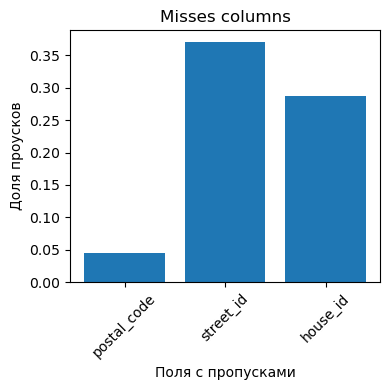

In [5]:
plt.figure(figsize = (4, 4))
plt.bar(mis.index, mis)

plt.xlabel('Поля с пропусками')
plt.ylabel('Доля проусков')
plt.title('Misses columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Получили доли пропущенных ячеек в разных колонках. Видно, что в ключевых для анализа колнках ВООБЩЕ нет пропусков. Датафрейм готов для анализа

Введем вспомогательные поля. Такие как стоимость за 1 квадратный метр для объекта (price_per_area), число объектов в регионе (count_by_region),

In [3]:
df['price_per_area'] = df['price'] / df['area']
df['price_per_area'] = df['price_per_area'].round()
df = df[df['price_per_area'] < 1000000]

df['count_by_region'] = df.groupby('id_region')['id_region'].transform('count')


#2 Исследовательский анализ

In [7]:
df.nlargest(5, 'price_per_area')

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id,price_per_area,count_by_region
773060,2021-02-07,37999962,5,5,2,38.0,6.0,54.237510,49.566414,0,0,433512.0,NaN,73,NaN,999999.0,40652
6409419,2021-08-01,134999000,9,16,3,135.0,20.0,55.725486,37.571825,0,0,119048.0,141633.0,77,1742868.0,999993.0,1022097
6278665,2021-07-28,57298000,5,5,1,57.3,0.0,43.408450,39.940775,0,0,354340.0,493131.0,23,1036727.0,999965.0,845860
11100910,2021-12-20,129990000,6,7,2,130.0,20.0,55.762181,37.547531,0,0,123100.0,371663.0,77,2741468.0,999923.0,1022097
9879647,2021-11-12,206469559,7,8,5,206.5,0.0,55.749603,37.597872,0,0,119019.0,314217.0,77,1831967.0,999853.0,1022097


In [13]:
price_per_m = df.groupby('id_region')['price_per_area'].agg(["mean",'median', 'count'])
print(price_per_m)
price_per_m = price_per_m.round()
print(price_per_m.nlargest(10, 'count').index)
print(price_per_m.nlargest(10, 'median').index)
print(price_per_m.nlargest(10, 'mean').index)

                    mean    median   count
id_region                                 
1           68736.878721   65833.0   20861
2           70439.302909   70833.0  220809
3           76277.479288   78608.0   47725
4           79773.032705   81132.0    2599
5           52492.502231   50000.0   46158
...                  ...       ...     ...
87          94815.312925  106041.0     147
89         114534.341929  125517.0    5235
91         117984.928432  102041.0   53711
92         131265.313386  126667.0   22643
200         93738.648309   90726.0    3577

[86 rows x 3 columns]
Index([77, 72, 23, 78, 50, 54, 24, 66, 61, 74], dtype='int64', name='id_region')
Index([77, 78, 65, 50, 92, 89, 47, 25, 23, 87], dtype='int64', name='id_region')
Index([77, 78, 65, 23, 50, 92, 47, 91, 89, 25], dtype='int64', name='id_region')


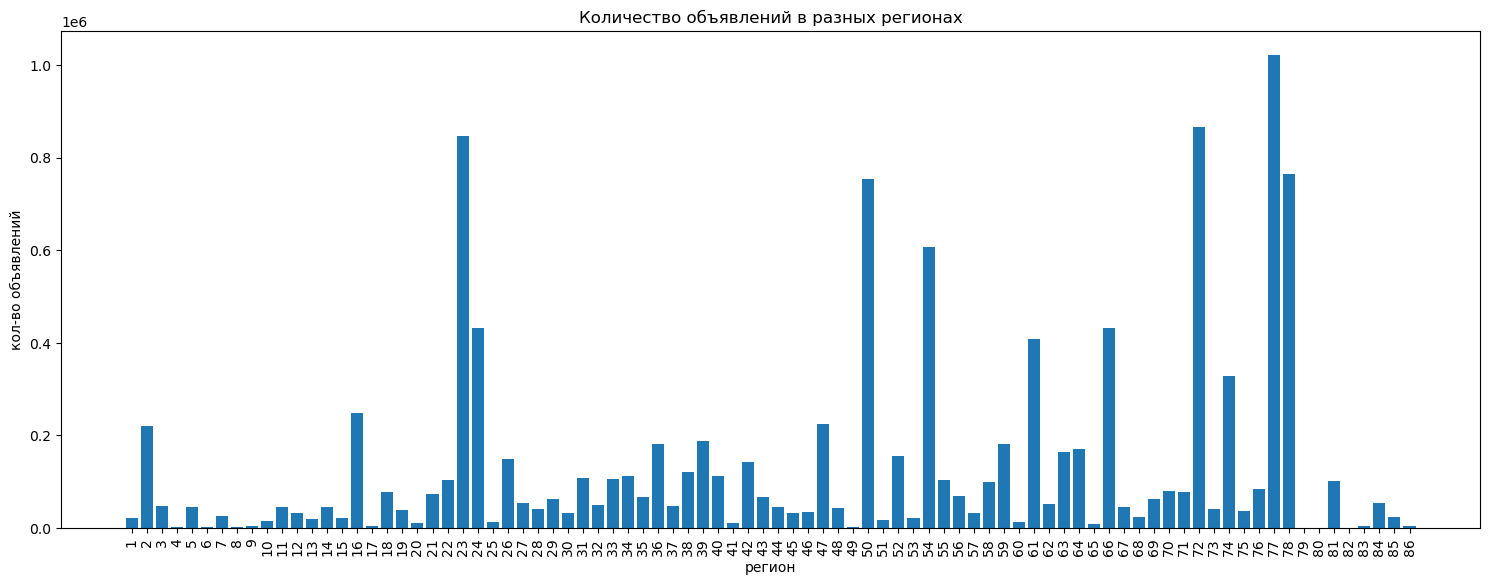

In [14]:
plt.figure(figsize = (15, 6))
plt.bar(np.arange(1, 87), price_per_m['count'])
plt.xlabel('регион')
plt.ylabel('кол-во объявлений')
plt.title('Количество объявлений в разных регионах')
plt.xticks(rotation=45)
plt.tight_layout()
plt.xticks(np.arange(1, 87), rotation = 90)
plt.show()

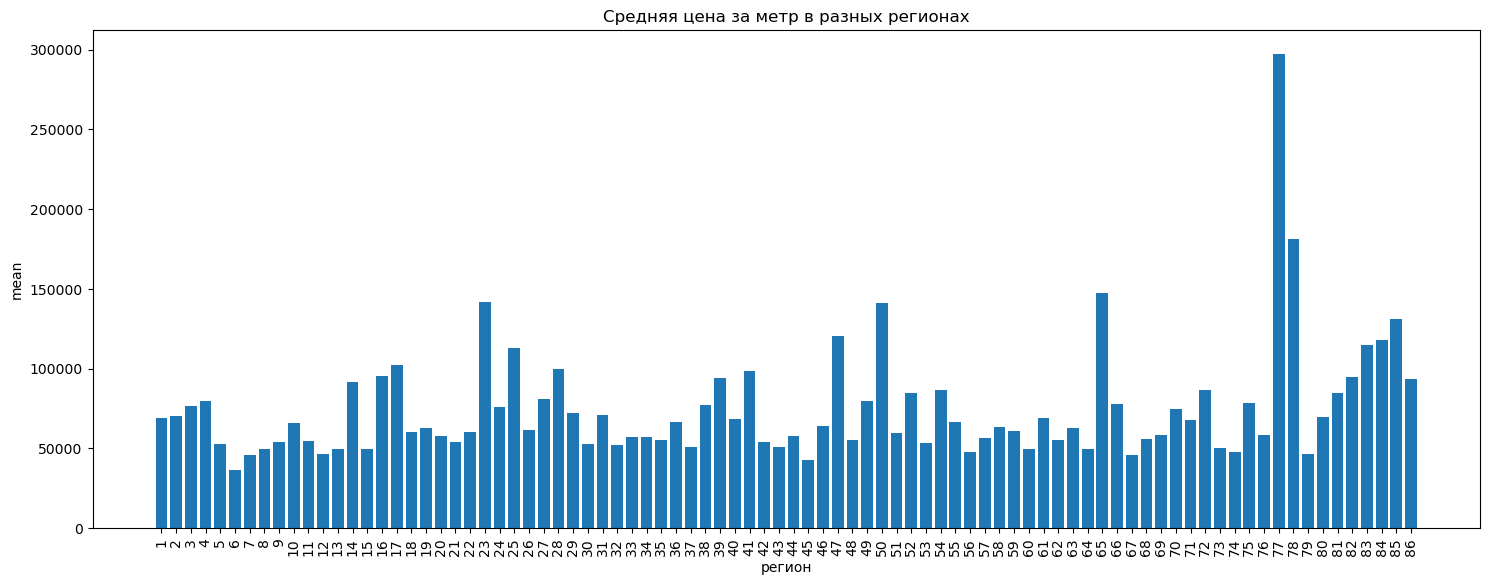

In [15]:
plt.figure(figsize = (15, 6))
plt.bar(np.arange(1, 87), price_per_m['mean'])
plt.xlabel('регион')
plt.ylabel('mean')
plt.title('Средняя цена за метр в разных регионах')
plt.xticks(rotation=45)
plt.tight_layout()
plt.xticks(np.arange(1, 87), rotation = 90)
plt.show()

Топы 10 регионов по...

Количеству объявлений: 77, 72, 23, 78, 50, 54, 24, 66, 61, 74

Размеру медианной стоимости квадратного метра: 77, 78, 65, 50, 92, 89, 47, 25, 23, 87

Размеру средней стоимости квадратного метра: 77, 78, 67, 17, 92, 23, 50, 65, 47, 25

Исследуем зависимость цены за квадратный метр от этажа и этажности

In [11]:
df.head()

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id,price_per_area,count_by_region
0,2021-01-01,2451300,15,31,1,30.3,0.0,56.780112,60.699355,0,2,620000.0,NaN,66,1632918.0,80901.0,430963
1,2021-01-01,1450000,5,5,1,33.0,6.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN,43939.0,20861
2,2021-01-01,10700000,4,13,3,85.0,12.0,55.540060,37.725112,3,0,142701.0,242543.0,50,681306.0,125882.0,754147
3,2021-01-01,3100000,3,5,3,82.0,9.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN,37805.0,20861
4,2021-01-01,2500000,2,3,1,30.0,9.0,44.738685,37.713668,3,2,353960.0,439378.0,23,1730985.0,83333.0,845860


Зависомость стоимости 1 квадратного метра от этажа квартиры

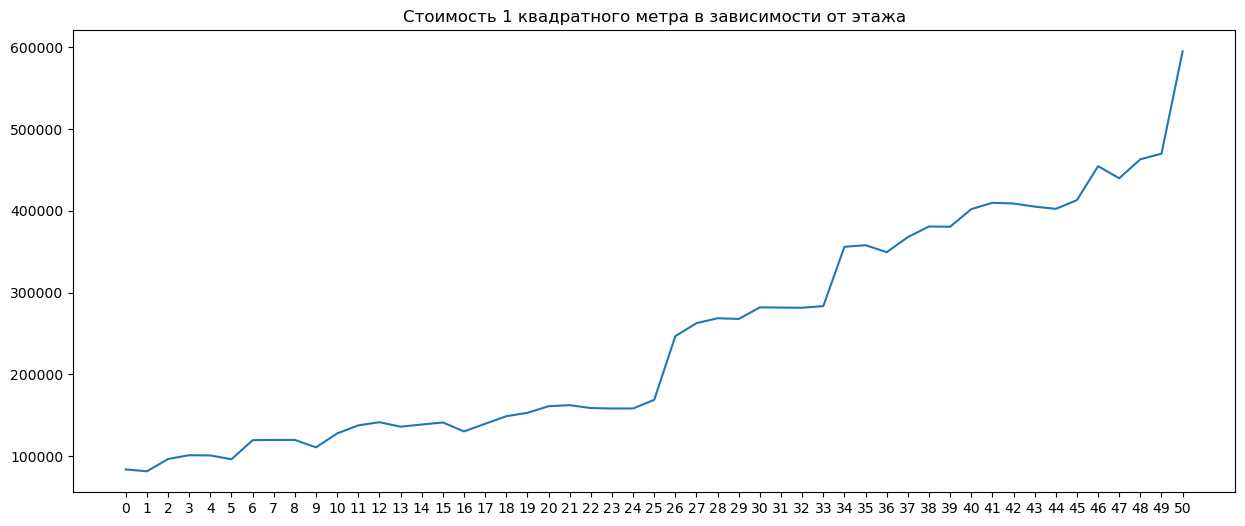

In [16]:
plt.figure(figsize = (15, 6))
ser = df.groupby('level')['price_per_area'].mean()
plt.xticks(ser.index)
plt.plot(ser.index, ser)
plt.title("Стоимость 1 квадратного метра в зависимости от этажа")
plt.show()

In [17]:
df2 = df[['level', 'levels', 'price_per_area']]
df2 = df2[(df2['levels'] <= 12) & (df2['level'] <= df2['levels'])]
df2


,level,levels,price_per_area
1,5,5,43939.0
3,3,5,37805.0
4,2,3,83333.0
5,5,5,30851.0
6,2,4,83799.0
...,...,...,...
11358145,4,9,93831.0
11358146,1,10,43761.0
11358147,2,2,22973.0
11358148,5,5,121111.0


Зависимость стоимости 1 метра от этажа квартиры в домах высотой до 12 этажей

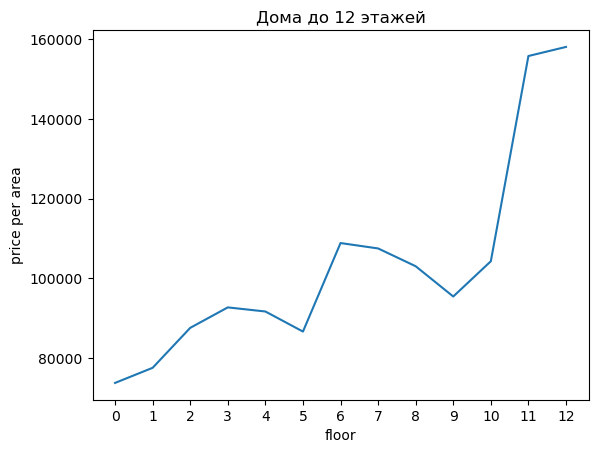

In [18]:
plt.figure()
ser1 = df2.groupby('level')['price_per_area'].mean()
plt.plot(ser1.index, ser1)
plt.xticks(ser1.index)
plt.title('Дома до 12 этажей')
plt.xlabel('floor')
plt.ylabel('price per area')
plt.show()

Гипотеза 1:


Цена 1 квадратного метра зависит от количества этажей в доме.

In [19]:
df3 = df[['levels', 'price_per_area']]
df3

,levels,price_per_area
0,31,80901.0
1,5,43939.0
2,13,125882.0
3,5,37805.0
4,3,83333.0
...,...,...
11358145,9,93831.0
11358146,10,43761.0
11358147,2,22973.0
11358148,5,121111.0


In [20]:
ser3 = df3.groupby('levels')['price_per_area'].mean()

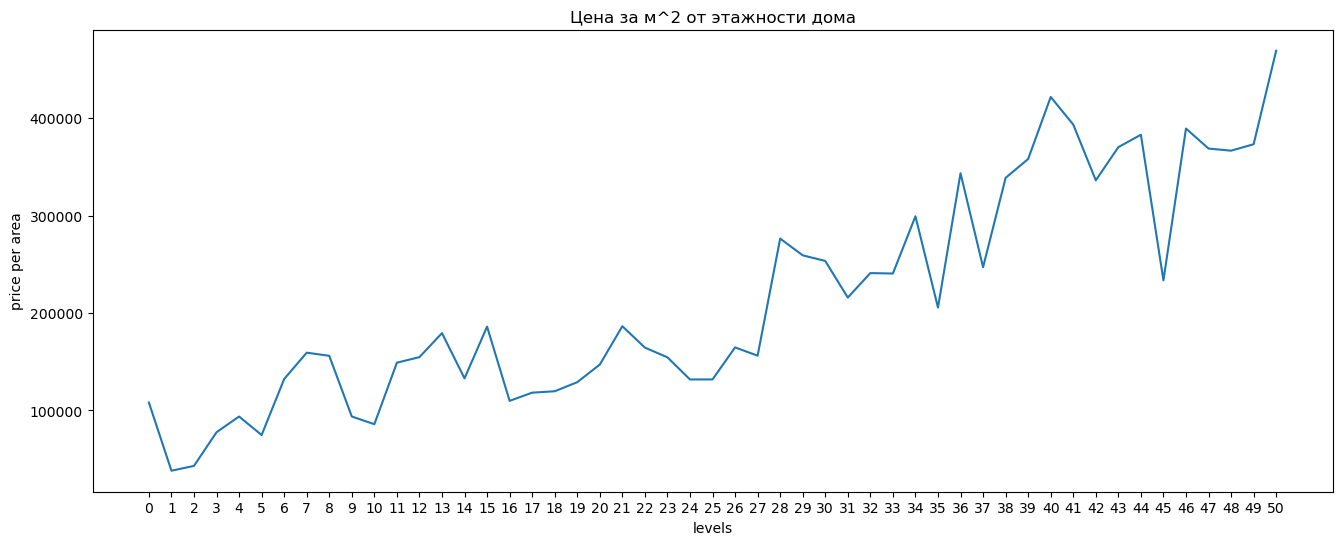

In [21]:
plt.figure(figsize = (16, 6))
plt.title('Цена за м^2 от этажности дома')
plt.xlabel('levels')
plt.ylabel('price per area')
plt.plot(ser3.index, ser3)
plt.xticks(ser.index)
plt.show()


Делем вывод, что цена зависит. При повышении этажности дома, наблюдается тренд повышения цены за метр.

Гипотеза 2:

Цена за м^2 у 1-комнатных выше, чем у 2-3 комнтаных

In [22]:
df4 = df[['rooms', 'price_per_area']]
#df4 = df4[(df4['rooms'] <= 3) & (df4['rooms'] > 0)]
ser4 = df4.groupby('rooms')['price_per_area'].mean()


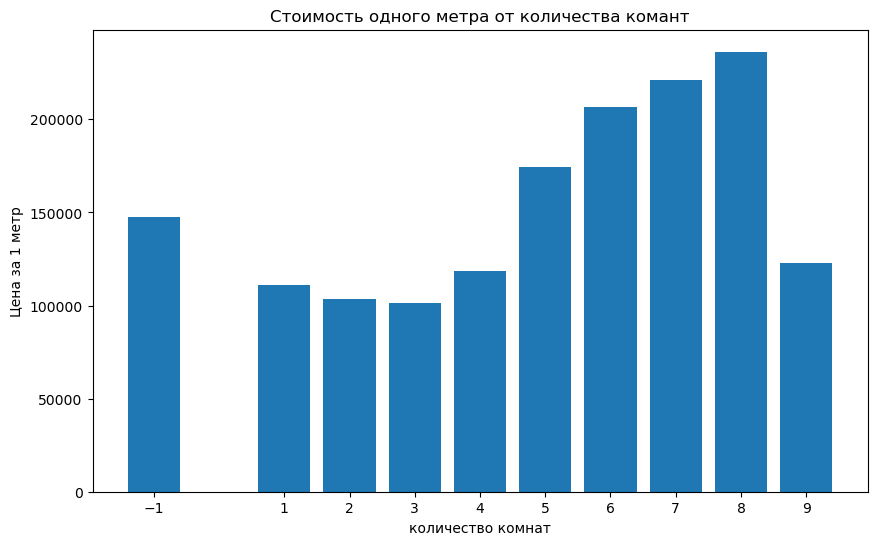

In [23]:
plt.figure(figsize = (10, 6))
plt.title('Стоимость одного метра от количества комант')
plt.xlabel('количество комнат')
plt.ylabel('Цена за 1 метр')
plt.bar(ser4.index, ser4)
plt.xticks(ser4.index)
plt.show()

Делаем вывод: в квартирах до трех комнат самая дорогая цена за квадратный метр у студий. Далее стоимость равномерно уменьшается до отметки в 3 комнаты. Далее резко возрастает. Самый дешевый метр -- в трехкомнатных квартирах.

Гипотеза 3: 

большая кухня повышает цену за квадратный метр

In [25]:
df5 = df[['area', 'kitchen_area', 'price_per_area']]
df5 = df5[(df5['kitchen_area'] >= 0) & (df5['kitchen_area'] <= df5['area'])]
df5['kitchen_rel'] = (df5['kitchen_area'] / df5['area']).round(2)


In [26]:
ser5 = df5.groupby('kitchen_rel')['price_per_area'].median()



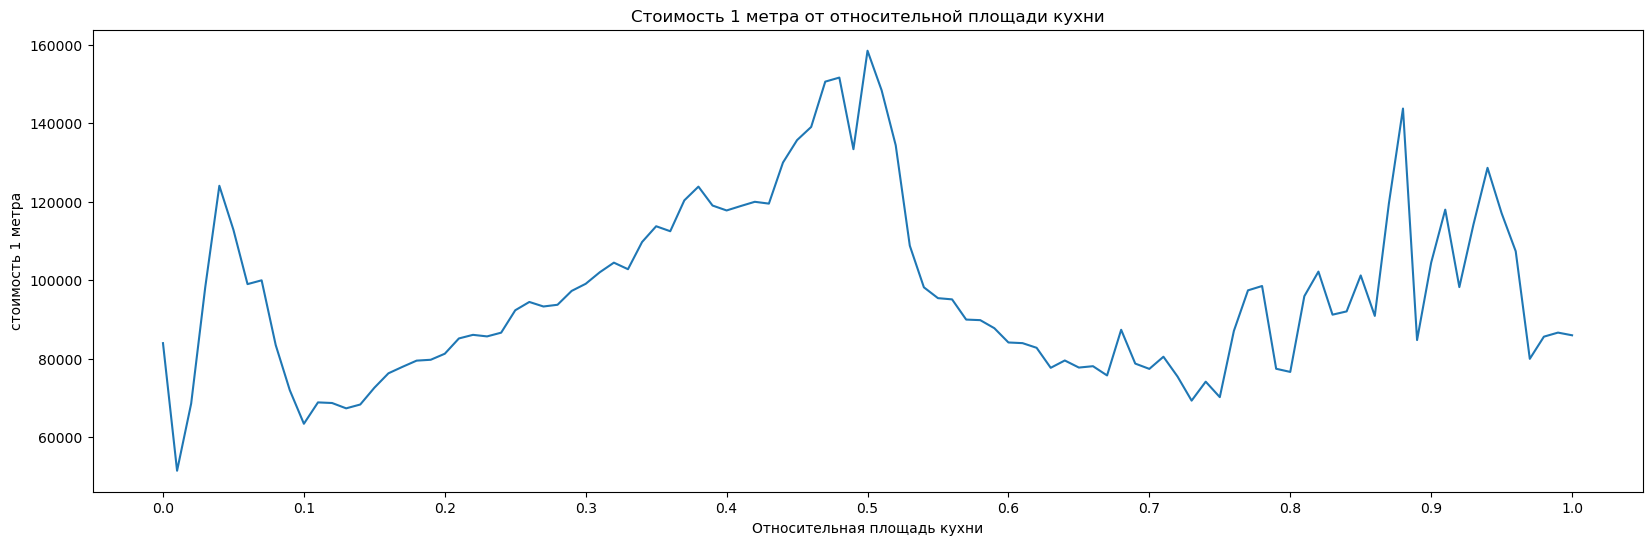

In [27]:
plt.figure(figsize = (20, 6))
plt.plot(ser5.index, ser5)
plt.xlabel('Относительная площадь кухни')
plt.ylabel('стоимость 1 метра')
plt.xticks(np.arange(0, 1.1, 0.1))
plt.title('Стоимость 1 метра от относительной площади кухни')
plt.show()

Выводы. На участке [0.1; 0.5]  наблюдается тренд повышения медианной цена за 1 метр. Можем сделать вывод, что гипотеза верна.

Построение предсказательных моделей.

1 -- Линейная регрессия 

In [ ]:
df["price_per_area"] = df["price"] / df["area"]
df["log_price_per_area"] = np.log(df["price_per_area"])

features = ["area", "kitchen_area", "rooms", "level", "levels", "id_region"]
target = "log_price_per_area"

df_ml = df[features + [target]].copy()

df_ml = df_ml.replace([np.inf, -np.inf], np.nan)
df_ml = df_ml.dropna(subset=[target] + features)

print(df_ml[target].describe())

c:\Users\ivana\anaconda3\envs\conda_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


count    1.133676e+07
mean     1.138275e+01
std      6.591830e-01
min     -4.248495e+00
25%      1.098390e+01
50%      1.132231e+01
75%      1.175352e+01
max      1.381551e+01
Name: log_price_per_area, dtype: float64


In [38]:
features = [
    "area", "kitchen_area", "rooms",
    "level", "levels", 'id_region'
]
target = "log_price_per_area"

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
df_ml_small = df_ml.sample(n=11000000, random_state=42)  

X = df_ml_small[features]
y = df_ml_small[target]
X.shape, y.shape

((11000000, 6), (11000000,))

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((8800000, 6), (2200000, 6))

In [47]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_log = linreg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("R^2:", round(r2, 3))

MAE: 0.43
R^2: 0.255


In [ ]:
y_true = np.exp(y_test)        
y_pred = np.exp(y_pred_log)   

In [49]:
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("MAE (руб/м²):", round(mae, 2))
print("R^2:", round(r2, 3))

MAE (руб/м²): 47168.39
R^2: 0.151


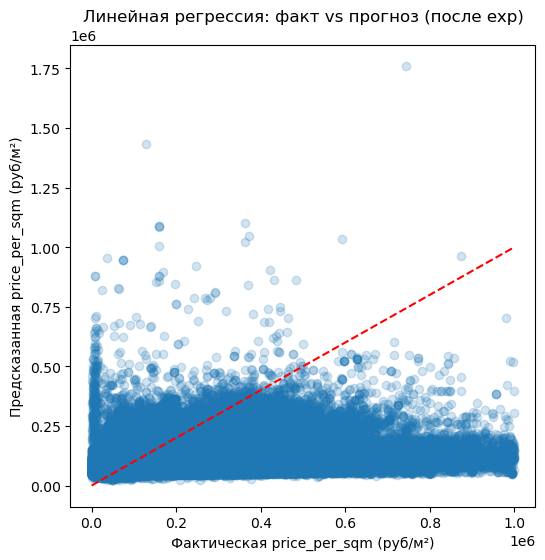

In [50]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.2)
plt.xlabel("Фактическая price_per_sqm (руб/м²)")
plt.ylabel("Предсказанная price_per_sqm (руб/м²)")
plt.title("Линейная регрессия: факт vs прогноз (после exp)")
plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    "r--"
)
plt.show()

2 -- Random Forest

In [ ]:
df["log_price_per_area"] = np.log(df["price_per_area"])


df["floor_rel"] = df["level"] / df["levels"]
df["kitchen_share"] = df["kitchen_area"] / df["area"]

features = [
    "area",
    "kitchen_area",
    "rooms",
    "level",
    "levels",   
    "id_region",
    "floor_rel",
    "kitchen_share"
]
target = "log_price_per_area"

df_ml = df[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()

df_ml.shape

c:\Users\ivana\anaconda3\envs\conda_env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(11334605, 9)

In [ ]:
df_ml_small = df_ml.sample(n=50_000, random_state=42)

num_features = [
    "area",
    "kitchen_area",
    "rooms",
    "level",
    "levels",
    "floor_rel",
    "kitchen_share"
]
cat_features = ["id_region"]

df_ml_small_dum = pd.get_dummies(df_ml_small[num_features + cat_features], columns=cat_features, drop_first=True)

X = df_ml_small_dum
y = df_ml_small[target]

X.shape, y.shape

((50000, 90), (50000,))

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((40000, 90), (10000, 90))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,   
    max_depth=12,      
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_log = rf.predict(X_test)

y_true = np.exp(y_test)
y_pred = np.exp(y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Random Forest MAE (руб/м²):", round(mae, 2))
print("Random Forest R^2:", round(r2, 3))

Random Forest MAE (руб/м²): 27171.29
Random Forest R^2: 0.694


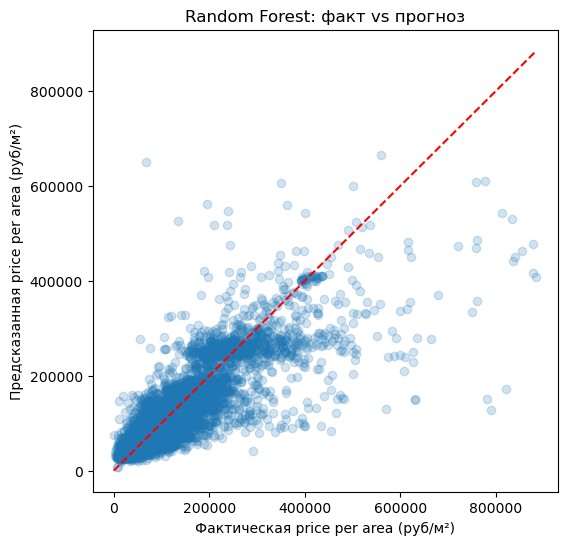

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.2)
plt.xlabel("Фактическая price per area (руб/м²)")
plt.ylabel("Предсказанная price per area (руб/м²)")
plt.title("Random Forest: факт vs прогноз")
plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    "r--"
)
plt.show()

In [10]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X.columns

for i in indices[:15]:
    print(feature_names[i], round(importances[i], 4))

id_region_77 0.4111
levels 0.1778
id_region_78 0.1409
id_region_50 0.0633
id_region_23 0.0547
area 0.0366
kitchen_share 0.0211
kitchen_area 0.016
id_region_74 0.0101
id_region_47 0.0098
floor_rel 0.0092
rooms 0.0079
id_region_39 0.0063
level 0.0061
id_region_54 0.0059


По графикам очевидно, что вторая модель предсказывает цену ощутимо лучше первой

Выводы по данным и рынку

- Цена за квадратный метр сильно различается между регионами: принадлежность объекта к конкретному региону (особенно Москве) объясняет значительную часть разброса цен.
- Этажность дома (общее количество этажей) заметно связана с ценой: высотные дома и дома определённого типа в среднем имеют более высокую цену за метр.
- Характеристики самой квартиры -- площадь, размер и доля кухни, количество комнат, положение по этажу -- также влияют на стоимость, но их вклад меньше, чем у локации.

Выводы по моделям

- Простая линейная регрессия на логарифме цены за метр показывает ограниченное качество (R² заметно ниже 1), но уже даёт лучшее качество, чем наивный baseline с прогнозом “средняя цена”.
- Использование логарифма таргета делает распределение более стабильным и уменьшает влияние экстремально дорогих и дешёвых объектов на обучение.
- Модель Random Forest на подвыборке данных улучшает качество прогноза по сравнению с линейной регрессией и лучше подстраивается под нелинейные зависимости между признаками и ценой.
- Анализ важности признаков в Random Forest подтверждает результаты EDA: наибольший вклад в предсказание вносит регион (особенно Москва), затем этажность дома, а далее — площадь, характеристики кухни и этаж квартиры.


Практические выводы

- При оценке стоимости новостройки первыми факторами, на которые нужно смотреть, являются регион и класс/этажность дома; уже внутри этих групп существенную роль играют планировка и размер квартиры.
